```markdown
# Clasificación de Dígitos Manuscritos con Regresión Logística

Este notebook implementa un clasificador de regresión logística para el conjunto de datos de dígitos manuscritos (una versión más pequeña del MNIST). Se incluyen los pasos de carga de datos, preprocesamiento, entrenamiento del modelo y evaluación de métricas clave de clasificación.
```

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, RocCurveDisplay
from sklearn.preprocessing import label_binarize

# Configuración para gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 7)
plt.rcParams['font.size'] = 12

```markdown
### 1. Carga del Conjunto de Datos

Cargamos el dataset `load_digits` de scikit-learn, que contiene imágenes de dígitos manuscritos de 8x8 píxeles.
```

Forma de los datos de características (X): (1797, 64)
Forma de las etiquetas (y): (1797,)
Número de clases: 10


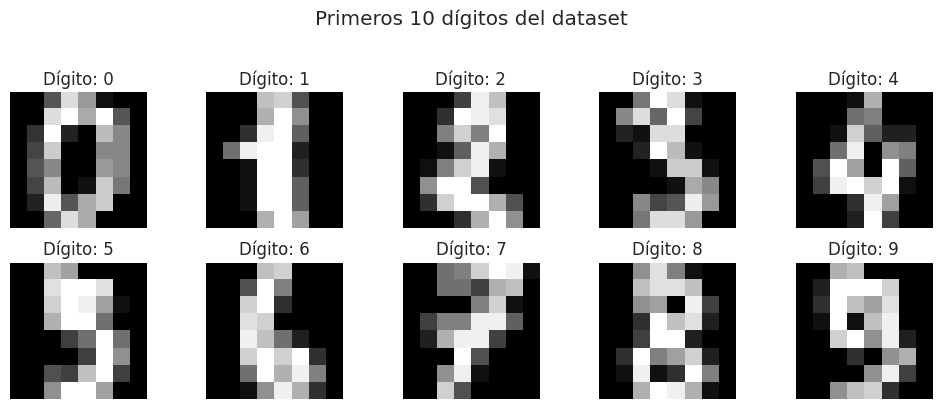

In [ ]:
digits = load_digits()
X = digits.data
y = digits.target

print(f"Forma de los datos de características (X): {X.shape}")
print(f"Forma de las etiquetas (y): {y.shape}")
print(f"Número de clases: {len(np.unique(y))}")

# Mostrar algunas de las imágenes de dígitos
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X[i].reshape(8, 8), cmap='gray')
    plt.title(f"Dígito: {y[i]}")
    plt.axis('off')
plt.suptitle('Primeros 10 dígitos del dataset', y=1.02)
plt.tight_layout()
plt.show()

```markdown
### 2. Preprocesamiento de Datos y División en Conjuntos de Entrenamiento/Prueba

Se escalan las características para mejorar el rendimiento del modelo de regresión logística y se dividen los datos en conjuntos de entrenamiento y prueba.
```

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Tamaño del conjunto de entrenamiento: {X_train_scaled.shape}")
print(f"Tamaño del conjunto de prueba: {X_test_scaled.shape}")

Tamaño del conjunto de entrenamiento: (1437, 64)
Tamaño del conjunto de prueba: (360, 64)


```markdown
### 3. Entrenamiento del Modelo de Regresión Logística

Se entrena un clasificador de regresión logística. Se especifica `solver='lbfgs'` para manejar problemas multi-clase y `max_iter` para asegurar la convergencia.
```

In [ ]:
model = LogisticRegression(solver='lbfgs', max_iter=5000, random_state=42)
model.fit(X_train_scaled, y_train)

print("Modelo de Regresión Logística entrenado.")
print(f"Precisión en el conjunto de entrenamiento: {model.score(X_train_scaled, y_train):.4f}")
print(f"Precisión en el conjunto de prueba: {model.score(X_test_scaled, y_test):.4f}")

Modelo de Regresión Logística entrenado.
Precisión en el conjunto de entrenamiento: 0.9993
Precisión en el conjunto de prueba: 0.9722


```markdown
### 4. Evaluación del Modelo

Ahora evaluaremos el rendimiento del modelo utilizando las métricas solicitadas:

*   **Matriz de Confusión**
*   **Reporte de Clasificación**
*   **Curva ROC y AUC**
*   **Histograma de errores (muestras mal clasificadas)**
```

In [ ]:
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)

```markdown
#### Matriz de Confusión

La matriz de confusión muestra el número de aciertos y errores por cada clase, permitiendo visualizar qué dígitos son confundidos con otros.
```

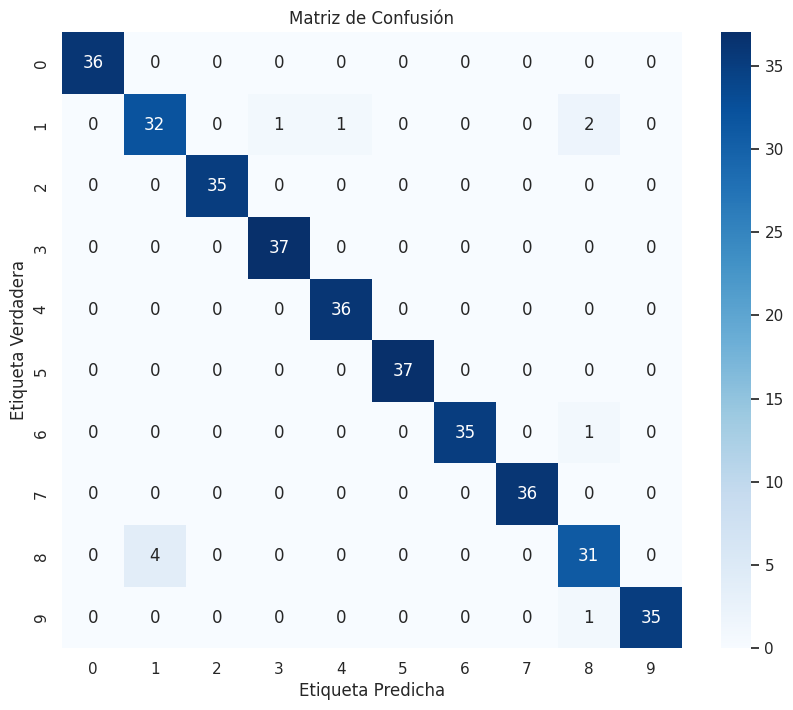

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=digits.target_names, yticklabels=digits.target_names)
plt.xlabel('Etiqueta Predicha')
plt.ylabel('Etiqueta Verdadera')
plt.title('Matriz de Confusión')
plt.show()

```markdown
#### Reporte de Clasificación

El reporte de clasificación proporciona métricas clave como precisión, recall, f1-score y soporte para cada clase, así como promedios macro y ponderados.
```

In [ ]:
report = classification_report(y_test, y_pred, target_names=[str(i) for i in digits.target_names])
print("\nReporte de Clasificación:\n")
print(report)


Reporte de Clasificación:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.89      0.89      0.89        36
           2       1.00      1.00      1.00        35
           3       0.97      1.00      0.99        37
           4       0.97      1.00      0.99        36
           5       1.00      1.00      1.00        37
           6       1.00      0.97      0.99        36
           7       1.00      1.00      1.00        36
           8       0.89      0.89      0.89        35
           9       1.00      0.97      0.99        36

    accuracy                           0.97       360
   macro avg       0.97      0.97      0.97       360
weighted avg       0.97      0.97      0.97       360



In [ ]:
#f1-score
2*(0.97*1)/(0.97+1)

0.9847715736040609

```markdown
#### Curva ROC y AUC (Para Clasificación Multiclase)

Para problemas de clasificación multiclase, la Curva ROC y el AUC se calculan generalmente utilizando la estrategia "uno contra el resto" (one-vs-rest). Esto implica binarizar las etiquetas y calcular una curva ROC para cada clase, comparándola con todas las demás.
```

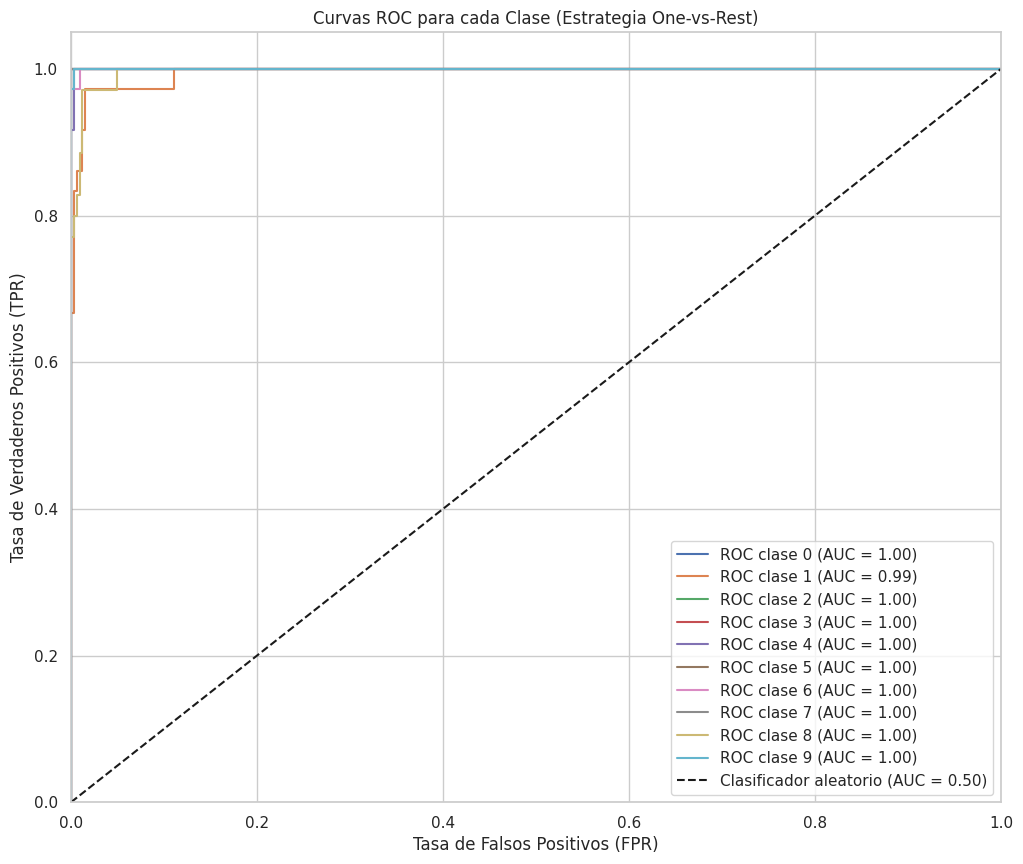

In [ ]:
# Binarizar las etiquetas para ROC de multiclase
y_test_binarized = label_binarize(y_test, classes=np.unique(y))
n_classes = y_test_binarized.shape[1]

plt.figure(figsize=(12, 10))

# Calcular y trazar ROC para cada clase
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_pred_proba[:, i])
    roc_auc = auc(fpr, tpr);
    plt.plot(fpr, tpr, label=f'ROC clase {i} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Clasificador aleatorio (AUC = 0.50)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curvas ROC para cada Clase (Estrategia One-vs-Rest)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

```markdown
#### Histograma de Errores (Visualización de Muestras Mal Clasificadas)

Aunque un "histograma de errores" no es una métrica estándar para clasificación en el mismo sentido que la matriz de confusión, podemos visualizar algunas de las imágenes que el modelo clasificó incorrectamente. Esto nos ayuda a entender dónde el modelo falla.
```

Total de muestras mal clasificadas: 10


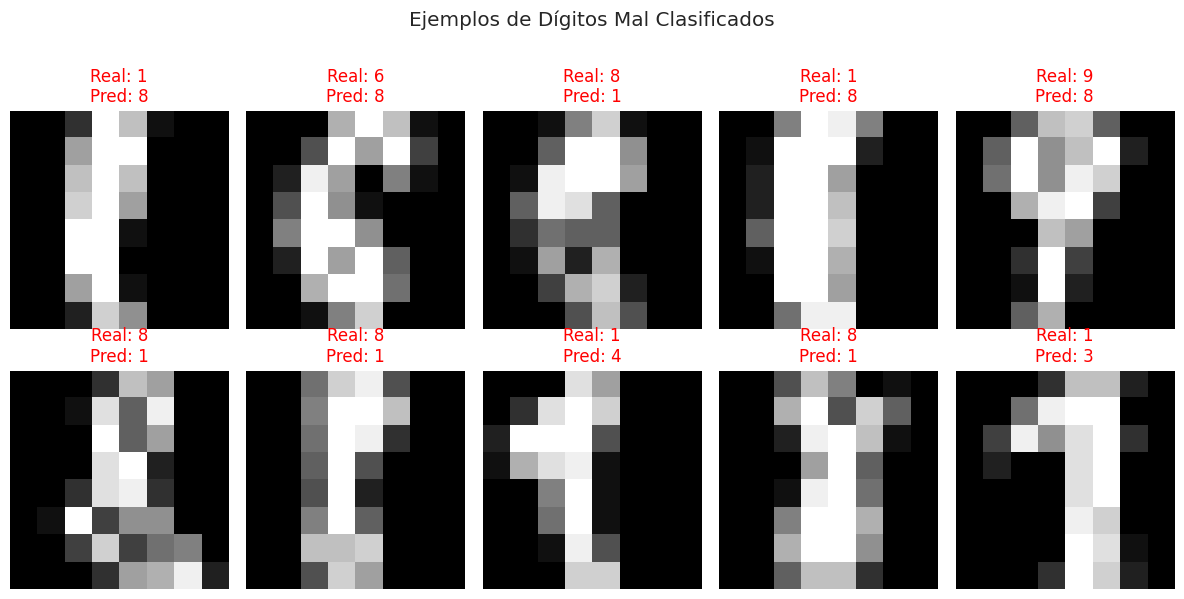

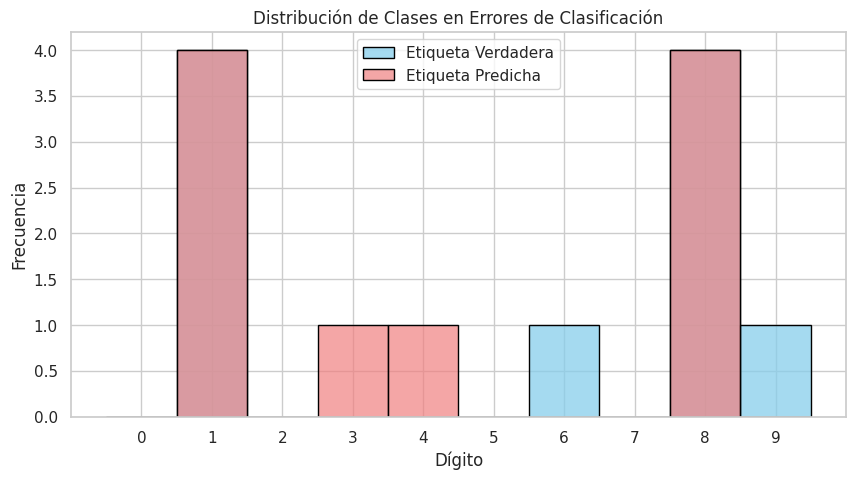

In [ ]:
# Encontrar los índices de las muestras mal clasificadas
misclassified_indices = np.where(y_pred != y_test)[0]

print(f"Total de muestras mal clasificadas: {len(misclassified_indices)}")

# Mostrar hasta 10 muestras mal clasificadas
plt.figure(figsize=(12, 6))
for i, bad_index in enumerate(misclassified_indices[:10]):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test[bad_index].reshape(8, 8), cmap='gray')
    plt.title(f"Real: {y_test[bad_index]}\nPred: {y_pred[bad_index]}", color='red')
    plt.axis('off')
plt.suptitle('Ejemplos de Dígitos Mal Clasificados', y=1.02)
plt.tight_layout()
plt.show()

# Opcional: Histograma de las clases predichas para los errores
if len(misclassified_indices) > 0:
    misclassified_true_labels = y_test[misclassified_indices]
    misclassified_predicted_labels = y_pred[misclassified_indices]

    plt.figure(figsize=(10, 5))
    sns.histplot(misclassified_true_labels, bins=np.arange(-0.5, n_classes + 0.5, 1),
                 kde=False, color='skyblue', edgecolor='black', label='Etiqueta Verdadera')
    sns.histplot(misclassified_predicted_labels, bins=np.arange(-0.5, n_classes + 0.5, 1),
                 kde=False, color='lightcoral', edgecolor='black', alpha=0.7, label='Etiqueta Predicha')
    plt.xticks(np.arange(0, n_classes, 1))
    plt.title('Distribución de Clases en Errores de Clasificación')
    plt.xlabel('Dígito')
    plt.ylabel('Frecuencia')
    plt.legend()
    plt.show()
else:
    print("¡No hay muestras mal clasificadas! Excelente rendimiento.")